**보강수업(LMS 영상 학습)**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

weather = pd.read_csv('./drive/MyDrive/weatherHistory.csv')
weather.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [8]:
xx = weather[['Humidity']]
yy = weather[['Temperature (C)']]
xx_train, xx_test, yy_train, yy_test = train_test_split(xx, yy, test_size=0.2, random_state=42)
reg = LinearRegression().fit(xx_train, yy_train)

In [9]:
reg.score(xx_train, yy_train)

0.4007432667666295

In [10]:
reg.score(xx_test, yy_test)

0.39578649233601315

In [11]:
reg.coef_

array([[-30.9101215]])

In [12]:
reg.intercept_

array([34.65474644])

In [13]:
yy_pred = reg.predict(xx_test)

In [14]:
print('MSE: %.2f' % mean_squared_error(yy_test, yy_pred))

MSE: 55.68


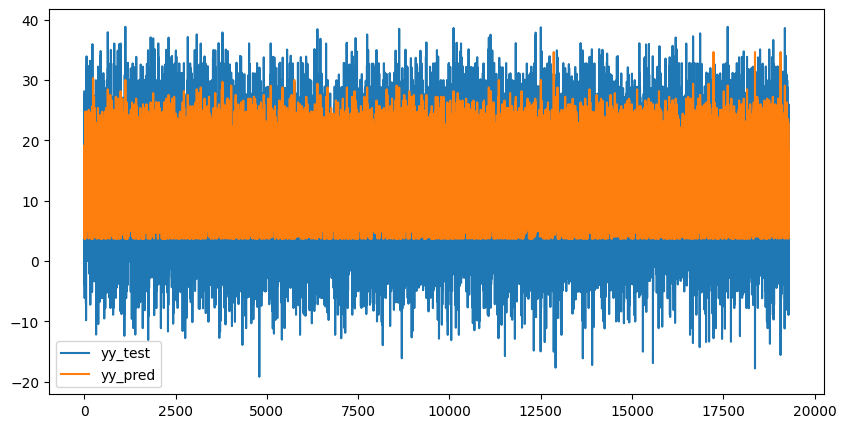

In [15]:
plt.figure(figsize=(10,5))
plt.plot(yy_test.to_numpy(), label='yy_test')
plt.plot(yy_pred, label='yy_pred')
plt.legend(loc=0)

In [16]:
weather = weather.drop(['Formatted Date', 'Summary', 'Precip Type', 'Daily Summary'], axis=1)
weather = weather.fillna(weather.mean())
X = weather.drop(['Temperature (C)'], axis=1)
y = weather['Temperature (C)']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg2 = LinearRegression().fit(X_train, y_train)

In [18]:
reg2.score(X_train, y_train)

0.9900989693577028

In [19]:
reg2.score(X_test, y_test)

0.9902437799520607

In [20]:
reg2.coef_

array([ 8.72566684e-01, -1.41898621e+00,  7.97670315e-02, -4.04011835e-04,
        8.62917874e-03,  0.00000000e+00, -2.05656529e-04])

In [21]:
reg2.intercept_

np.float64(2.831985728894649)

In [22]:
y_pred = reg2.predict(X_test)

In [23]:
print('MSE: %.2f' % mean_squared_error(y_test, y_pred))

MSE: 0.90


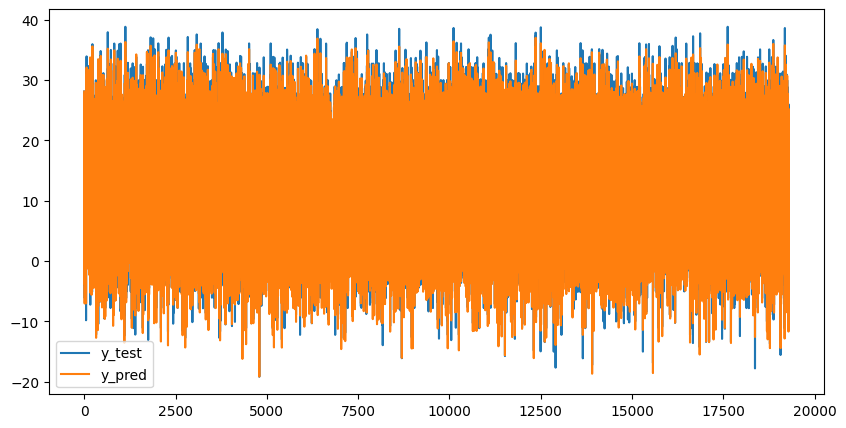

In [24]:
plt.figure(figsize=(10,5))
plt.plot(y_test.to_numpy(), label='y_test')
plt.plot(y_pred, label='y_pred')
plt.legend(loc=0)

In [25]:
new = np.array([[0.75, 0.55, 5.0, 180, 10, 0, 1015.0]])
new_pred = reg2.predict(new)
print(new_pred)

[2.90963176]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**로지스틱 회귀 보강수업(LMS 영상 학습) p74~**

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

In [27]:
data = load_iris()
data.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [28]:
data.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [29]:
data.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [30]:
X, y = load_iris(return_X_y=True)

In [31]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [32]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [33]:
X[:3,:]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2]])

In [34]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

In [35]:
x_scaled[:3,:]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ]])

In [36]:
clf = LogisticRegression(random_state=0, max_iter=200).fit(x_scaled,y)

In [37]:
clf.score(x_scaled,y)

0.9733333333333334

In [38]:
clf.predict(x_scaled[:3,:])

array([0, 0, 0])

In [39]:
clf.predict_proba(x_scaled[:3,:])

array([[9.84703167e-01, 1.52967711e-02, 6.20377714e-08],
       [9.43549042e-01, 5.64505708e-02, 3.87066866e-07],
       [9.82187999e-01, 1.78119126e-02, 8.81501117e-08]])

In [40]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

bc = load_breast_cancer()
bc.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [41]:
bc.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [42]:
bc.target_names

array(['malignant', 'benign'], dtype='<U9')

In [43]:
X, y = load_breast_cancer(return_X_y=True)
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [44]:
clf = LogisticRegression(random_state=0).fit(X, y)

In [45]:
clf.predict(X[:3,:])

array([0, 0, 0])

In [46]:
clf.predict_proba(X[:3, :])

array([[9.99999999e-01, 1.21582024e-09],
       [9.99968188e-01, 3.18123357e-05],
       [9.99999837e-01, 1.63464432e-07]])

In [47]:
clf.score(X,y)

0.9876977152899824

In [48]:
clf.coef_

array([[-0.37545731, -0.38203064, -0.36097105, -0.43946905, -0.16737642,
         0.56070701, -0.85529546, -0.96284928,  0.07631246,  0.3284581 ,
        -1.28926139,  0.26511648, -0.6718954 , -0.99886093, -0.27950865,
         0.74407728,  0.1012066 , -0.32314492,  0.29504386,  0.68174616,
        -1.02658552, -1.32055634, -0.82039667, -0.99467101, -0.66571519,
         0.05114225, -0.88022314, -0.92517516, -0.88871131, -0.48699036]])

In [49]:
clf.intercept_

array([0.22088611])

**로지스틱 회귀 실습1**

In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

people = pd.read_csv('./drive/MyDrive/Titanic_train.csv')
people.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [52]:
people.shape

(891, 12)

In [53]:
people['Sex'] = people['Sex'].map({'male':0, 'female':1})
people['Age'].fillna(value=people['Age'].mean(), inplace=True)
people['Embarked'] = people['Embarked'].map({'S':1, 'C':2, 'Q':3})
people['Embarked'].fillna(value=3, inplace=True)

/tmp/ipython-input-4088880350.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  people['Age'].fillna(value=people['Age'].mean(), inplace=True)
/tmp/ipython-input-4088880350.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

In [55]:
feature = people[['Sex', 'Age', 'Pclass', 'Embarked']]
target = people['Survived']

In [56]:
train_feature, test_feature, train_target, test_target = train_test_split(feature, target)

In [57]:
scaler = StandardScaler()
train_feature = scaler.fit_transform(train_feature)
test_feature = scaler.transform(test_feature)

In [58]:
clf = LogisticRegression()
clf.fit(train_feature, train_target)

LogisticRegression()

In [59]:
clf.score(train_feature, train_target)

0.8038922155688623

In [63]:
clf.score(test_feature, test_target)

0.7533632286995515

In [64]:
clf.coef_

array([[ 1.2740333 , -0.49576331, -0.99698805,  0.1721403 ]])

<Axes: xlabel='Survived', ylabel='count'>

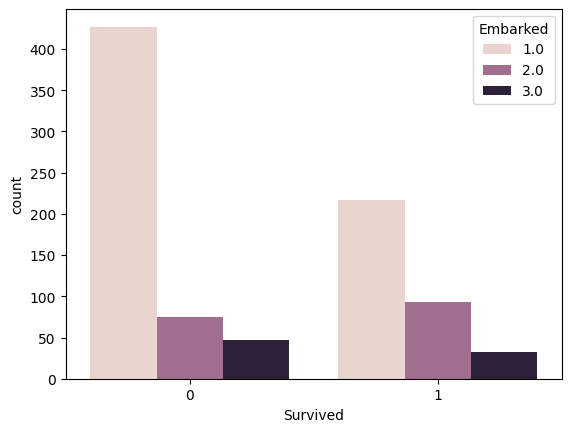

In [70]:
import seaborn as sns
sns.countplot(x='Survived', hue='Embarked', data=people)

In [72]:
import numpy as np
Jack = np.array([0.0, 20.0, 2.0, 2.0])
Rose = np.array([1.0, 17.0, 1.0, 3.0])
ME = np.array([0.0, 44.0, 3.0, 3.0])
sample = np.array([Jack, Rose, ME])
sample = scaler.transform(sample)
print(clf.predict(sample))
print(clf.predict_proba(sample))

[0 1 0]
[[0.67299049 0.32700951]
 [0.0287301  0.9712699 ]
 [0.92861797 0.07138203]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


**로지스틱 회귀 실습2**

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [74]:
data = pd.read_csv('./drive/MyDrive/weatherHistory.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [75]:
data.isnull().sum()

,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


In [76]:
data['Precip Type'].fillna(value='rain', inplace=True)
data.isnull().sum()

/tmp/ipython-input-88729060.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Precip Type'].fillna(value='rain', inplace=True)


,0
Formatted Date,0
Summary,0
Precip Type,0
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


In [77]:
data['Precip Type'] = data['Precip Type'].map({'rain':0, 'snow':1}).astype(int)

In [90]:
features = data[['Temperature (C)', 'Humidity', 'Wind Speed (km/h)']]
target = data['Precip Type']
train_features, test_features, train_target, test_target=train_test_split(features,target,test_size=0.2, shuffle=False)

In [91]:
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

In [93]:
clf = LogisticRegression().fit(train_features, train_target)
print(clf.score(train_features, train_target))
print(clf.score(test_features, test_target))

0.9958140017106866
0.9970970919081437


In [94]:
DU = np.array([32.0, 0.65, 2])
Pohang = np.array([15.1, 0.84, 2.4])
Seoul = np.array([24.1, 0.75, 2.5])
Seoulwinter = np.array([-6.0, 0.74, 2.9])
Daegu = np.array([0.0, 0.25, 2.0])
sample = np.array([DU, Pohang, Seoul, Seoulwinter, Daegu])
sample = scaler.transform(sample)
print(clf.predict(sample))
print(clf.predict_proba(sample))

[0 0 0 1 1]
[[1.00000000e+00 2.03531310e-43]
 [1.00000000e+00 7.48442110e-21]
 [1.00000000e+00 7.15277595e-33]
 [7.21424787e-09 9.99999993e-01]
 [3.61577834e-01 6.38422166e-01]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
